In [1]:
import os
import glob
import re
from typing import Dict, List, Tuple, Optional
import vtk
import numpy as np
import pandas as pd
import pyvista as pv

In [2]:
def duplicate_cycles(df_base: pd.DataFrame, cycle_length: int, n_cycles: int) -> pd.DataFrame:
    """
    Duplica un DataFrame con columna 'Time' para replicar ciclos.
    """
    dfs = []
    for i in range(n_cycles):
        df_tmp = df_base.copy()
        df_tmp["Time"] = df_tmp["Time"] + i * cycle_length
        dfs.append(df_tmp)
    return pd.concat(dfs, ignore_index=True)


def ensure_dir(path: str) -> None:
    if path and not os.path.exists(path):
        os.makedirs(path, exist_ok=True)

In [44]:
def zone_centroids(path, folder_results, save_dir, cycle_len = 430, n_cycles = 5, zones = ("fo", "tv")):
    """
    Extrae centroides de los bloques indicados en cada timestep único del .encas,
    y luego duplica ciclos.
    """
    if save_dir is not None:
        ensure_dir(save_dir)

    case_file = path + "TT2.encas"
    reader = vtk.vtkGenericEnSightReader()
    reader.SetCaseFileName(case_file)
    reader.ReadAllVariablesOn()
    reader.UpdateInformation()

    info = reader.GetOutputInformation(0)
    time_steps = info.Get(vtk.vtkStreamingDemandDrivenPipeline.TIME_STEPS())

    if time_steps is None or len(time_steps) == 0:
        raise RuntimeError("No se encontraron TIME_STEPS en el caso EnSight.")

    time_steps_unique = time_steps[:cycle_len]

    centroids_dict = {z.lower(): [] for z in zones}

    for t_idx, t in enumerate(time_steps_unique, start=1):
        print(f"--- Unique step {t_idx}/{cycle_len} | t = {t} ---")

        reader.GetOutputInformation(0).Set(vtk.vtkStreamingDemandDrivenPipeline.UPDATE_TIME_STEP(), t)
        reader.Update()

        output = reader.GetOutput()

        for zona in zones:
            zona_lower = zona.lower()

            it = output.NewIterator()
            it.InitTraversal()
            target_block = None

            while not it.IsDoneWithTraversal():
                meta = output.GetMetaData(it)
                name = meta.Get(vtk.vtkCompositeDataSet.NAME()) if meta is not None else None

                if name and name.lower() == zona_lower:
                    target_block = it.GetCurrentDataObject()
                    break
                it.GoToNextItem()

            surface = vtk.vtkDataSetSurfaceFilter()
            surface.SetInputData(target_block)
            surface.Update()

            mesh = pv.wrap(surface.GetOutput())
            pts = mesh.points

            cx, cy, cz = pts.mean(axis=0)
            centroids_dict[zona_lower].append([t_idx, float(cx), float(cy), float(cz)])

    dfs = {}
    for zona in zones:
        zona_lower = zona.lower()
        df_base = pd.DataFrame(centroids_dict[zona], columns=["Time", "x", "y", "z"])
        df_full = duplicate_cycles(df_base, cycle_length=cycle_len, n_cycles=n_cycles)
        dfs[zona_lower] = df_full

        filename = f"{zona}_coordinates_{folder_results}.csv"
        df_full.to_csv(os.path.join(save_dir, filename), index=False)

    print("Coordenadas guardadas")
    return 

In [37]:
def closer_out_particles(base_path, folder_results, save_dir, origin_particles, path_FO, path_TV):
    N_PARTICLES = 2151*10*3
    #base_path = "D:/Export_funciona_final3/" #"Z:/physense/InmaVillanueva/10IVC/funciona_final3/result/"
    mpg_files = sorted(glob.glob(base_path + "TT2_parti_" + origin_particles + ".mpg*")) #[base_path + "TT2_parti.mpg1291"] #
    
    # Columnas: particle_id, last_time_step, x, y, z
    data = np.zeros((N_PARTICLES, 5), dtype=float)
    data[:, 0] = np.arange(1, N_PARTICLES + 1)  # particle_id
    
    
    for mpg_file in mpg_files:
        timestep = int(re.search(r"mpg(\d+)", mpg_file).group(1))
        print(f"Procesando timestep {timestep}")
    
        with open(mpg_file, "r") as f:
            lines = f.readlines()
    
        # Encontrar inicio de coordenadas
        for i, line in enumerate(lines):
            if "particle coordinates" in line.lower():
                start = i + 2
                break
    
        n_particles = int(lines[start - 1].strip())
    
        number_pattern = re.compile(r"[+-]?\d+(?:\.\d+)?(?:e[+-]?\d+)?")
        
        for line in lines[start:start + n_particles]:
        
            nums = number_pattern.findall(line)
        
            if len(nums) < 4:
                print("No pattern match:", line.strip())
                continue
        
            pid = int(nums[0])
            x = float(nums[1])
            y = float(nums[2])
            z = float(nums[3])
    
            row = pid - 1
            data[row, 1] = timestep
            data[row, 2] = x
            data[row, 3] = y
            data[row, 4] = z
    
    particles_df = pd.DataFrame(
        data,
        columns=["particle_id", "last_time_step", "x", "y", "z"]
    )
    particles_df = particles_df[particles_df["last_time_step"] > 0]

    TV_df = pd.read_csv(path_TV)  
    FO_df = pd.read_csv(path_FO) 
    
    # Crear diccionarios: Time -> coordenadas del centroide
    tv_centroids = TV_df.set_index("Time")[["x", "y", "z"]].to_dict(orient="index")
    fo_centroids = FO_df.set_index("Time")[["x", "y", "z"]].to_dict(orient="index")
    
    results = []
    
    for idx, row in particles_df.iterrows():
        pid = row["particle_id"]
    
        if idx % 1000 == 0:
            print(f"Procesando partícula {pid} (iteración {idx})")
    
        t = row["last_time_step"]
        px, py, pz = row["x"], row["y"], row["z"]
    
        min_dist = np.inf
        nearest_block = None
        dist_fo = np.nan
        dist_tv = np.nan
    
        # Distancia al centroide de FO
        if t in fo_centroids:
            fx, fy, fz = fo_centroids[t]["x"], fo_centroids[t]["y"], fo_centroids[t]["z"]
            dist_fo = np.sqrt((px - fx)**2 + (py - fy)**2 + (pz - fz)**2)
            if dist_fo < min_dist:
                min_dist = dist_fo
                nearest_block = "FO"
    
        # Distancia al centroide de TV
        if t in tv_centroids:
            tx, ty, tz = tv_centroids[t]["x"], tv_centroids[t]["y"], tv_centroids[t]["z"]
            dist_tv = np.sqrt((px - tx)**2 + (py - ty)**2 + (pz - tz)**2)
            if dist_tv < min_dist:
                min_dist = dist_tv
                nearest_block = "TV"
    
        results.append([pid, t, px, py, pz, nearest_block, min_dist, dist_fo, dist_tv])
    
    result_df = pd.DataFrame(
        results, columns=["particle_id", "time_step", "x", "y", "z", "nearest_block", "distance", "distance_to_FO", "distance_to_TV",])
    
    result_df.to_excel(os.path.join(save_dir, f"closer_{origin_particles}_{folder_results}.xlsx"), index=False)
    print("Archivo generado: particula_cercana.xlsx")

In [40]:
def read_out(filepath):
    data = []

    with open(filepath, 'r') as f:
        for line in f:
            # Saltar líneas que no empiezan con números
            if not line.strip() or not line[0].isdigit():
                continue
            
            # Convertir la línea en números
            vals = line.split()
            if len(vals) >= 3:  
                data.append([float(vals[1]), float(vals[2]), float(vals[3]), float(vals[4]), float(vals[5]), float(vals[6])])  # report-flow-in, flow-time

    data = np.array(data)
    flow1 = data[:, 0]
    flow2 = data[:, 1]
    flow3 = data[:, 2]
    flow4 = data[:, 3]
    flow5 = data[:, 4]
    flow_time = data[:, 5]

    return flow1, flow2, flow3, flow4, flow5, flow_time

def compute_particle_count_proportions(path_outfile, particles_file, cycle):
    
    # Calcular proporción de flujo del DV que van a FO o a TV en el último ciclo
    flow_dv_ansys, flow_fo_ansys, flow_ivc_ansys, flow_svc_ansys, flow_tv_ansys, time_ansys = read_out(path_outfile)
    
    # Repetir flujo por partícula
    if "dv" in particles_file:
        flow_source = flow_dv_ansys
    elif "ivc" in particles_file:
        flow_source = flow_ivc_ansys
    elif "svc" in particles_file:
        flow_source = flow_svc_ansys
    particles_flow = np.repeat(flow_source, 30)                
    
    input_file = particles_file
    df = pd.read_excel(input_file)
    
    df = df[(df["time_step"] >= 1720) & (df["time_step"] <= 2150) & (df["distance"] < 0.02)]
    
    # Asignar flujo a cada partícula 
    df["particle_flow"] = particles_flow[df["particle_id"].values - 1]
    
    flow_counts = (
        df.groupby(["time_step", "nearest_block"])["particle_flow"]
          .sum()
          .unstack(fill_value=0)
          .reset_index()
    )
    
    flow_counts = flow_counts[["time_step", "FO", "TV"]]
    total_FO = flow_counts["FO"].sum()
    total_TV = flow_counts["TV"].sum()

    proportion_FO = np.round(100*total_FO/(total_FO + total_TV),2)
    proportion_TV = np.round(100*total_TV/(total_FO + total_TV),2)
    
    return proportion_FO, proportion_TV

In [45]:
v_base_path = ["D:/Export_reference/"]
v_folder_results = ["reference"]
v_save_dir = ["./Export_reference/",]
v_path_outfile = [r"D:/report-flow_reference-rfile.out"]

v_cycle = [5]

for cycle in v_cycle:
    results_FO = []
    results_TV = []
    for ii in range(len(v_base_path)):
        base_path = v_base_path[ii]
        folder_results = v_folder_results[ii]
        save_dir = v_save_dir[ii]
        path_outfile = v_path_outfile[ii]
    
        print(folder_results)
    
        path_FO = os.path.join(save_dir, f"FO_coordinates_{folder_results}.csv")
        path_TV = os.path.join(save_dir, f"TV_coordinates_{folder_results}.csv")
    
        v_origin_particles = ["dv", "ivc", "svc"]
        v_proportion_FO = []
        v_proportion_TV = []
    
        #zone_centroids(base_path, folder_results, save_dir, cycle_len=4300, n_cycles=5, zones=("fo", "tv"))
    
        for origin_particles in v_origin_particles:
            closer_out_particles(base_path, folder_results, save_dir, origin_particles, path_FO, path_TV)
            particles_file = os.path.join(save_dir, f"closer_{origin_particles}_{folder_results}.xlsx")
            proportion_FO, proportion_TV = compute_particle_count_proportions(path_outfile, particles_file, cycle)
    
            v_proportion_FO.append(proportion_FO)
            v_proportion_TV.append(proportion_TV)
    
        print(f"proportion FO = {v_proportion_FO}")
        print(f"proportion TV = {v_proportion_TV}")
    
        # Guardar una fila para FO
        results_FO.append({"simulation": folder_results, "DV": v_proportion_FO[0], "IVC": v_proportion_FO[1], "SVC": v_proportion_FO[2]})
    
        # Guardar una fila para TV
        results_TV.append({"simulation": folder_results, "DV": v_proportion_TV[0], "IVC": v_proportion_TV[1], "SVC": v_proportion_TV[2]})
    
    # Convertir a DataFrames
    df_FO = pd.DataFrame(results_FO)
    df_TV = pd.DataFrame(results_TV)
    
    # Ruta del Excel final
    excel_path = f"particle_proportions_summary_reference.xlsx"
    
    # Guardar en dos pestañas
    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        df_FO.to_excel(writer, sheet_name="FO", index=False)
        df_TV.to_excel(writer, sheet_name="TV", index=False)
    
    print(f"Excel guardado en: {excel_path}")
   

1e-4
--- Unique step 1/4300 | t = 0.0001 ---
--- Unique step 2/4300 | t = 0.0002 ---
--- Unique step 3/4300 | t = 0.0003 ---
--- Unique step 4/4300 | t = 0.0004 ---
--- Unique step 5/4300 | t = 0.0005 ---
--- Unique step 6/4300 | t = 0.0006 ---
--- Unique step 7/4300 | t = 0.0007 ---
--- Unique step 8/4300 | t = 0.0008 ---
--- Unique step 9/4300 | t = 0.0009 ---
--- Unique step 10/4300 | t = 0.001 ---
--- Unique step 11/4300 | t = 0.0011 ---
--- Unique step 12/4300 | t = 0.0012 ---
--- Unique step 13/4300 | t = 0.0013 ---
--- Unique step 14/4300 | t = 0.0014 ---
--- Unique step 15/4300 | t = 0.0015 ---
--- Unique step 16/4300 | t = 0.0016 ---
--- Unique step 17/4300 | t = 0.0017 ---
--- Unique step 18/4300 | t = 0.0018 ---
--- Unique step 19/4300 | t = 0.0019 ---
--- Unique step 20/4300 | t = 0.002 ---
--- Unique step 21/4300 | t = 0.0021 ---
--- Unique step 22/4300 | t = 0.0022 ---
--- Unique step 23/4300 | t = 0.0023 ---
--- Unique step 24/4300 | t = 0.0024 ---
--- Unique step 25/430

In [72]:
def particles_timestep(path_out,excel_particles):
    flow_dv_ansys, flow_fo_ansys, flow_ivc_ansys, flow_svc_ansys, flow_tv_ansys, time_ansys = read_out(path_out)
    
    # Repetir flujo por partícula
    if "dv" in excel_particles:
        flow_source = flow_dv_ansys
    elif "ivc" in excel_particles:
        flow_source = flow_ivc_ansys
    elif "svc" in excel_particles:
        flow_source = flow_svc_ansys
    particles_flow = np.repeat(flow_source, 30)
    
    # Leer archivo de partículas
    df = pd.read_excel(excel_particles)
    
    # Filtrar time steps y distancia
    df = df[(df["time_step"] >= 1720) & (df["time_step"] <= 2150) & (df["distance"] < 0.02)]
    
    # Asignar flujo a cada partícula
    df["particle_flow"] = particles_flow[df["particle_id"].values - 1]
    
    # Sumar flujo por time_step y bloque más cercano
    flow_ts = (
        df.groupby(["time_step", "nearest_block"])["particle_flow"]
        .sum()
        .unstack(fill_value=0)
    )

    # Asegurar que todos los timesteps estén presentes
    all_timesteps = np.arange(1720, 2150)  # (17200, 21501)
    flow_ts = flow_ts.reindex(all_timesteps, fill_value=0)

    # Reset index para volver a columna
    flow_ts = flow_ts.reset_index().rename(columns={"index": "time_step"})
    
    # Asegurar columnas FO y TV
    for col in ["FO", "TV"]:
        if col not in flow_ts.columns:
            flow_ts[col] = 0.0
    
    flow_ts = flow_ts[["time_step", "FO", "TV"]]
    
    return flow_ts

In [73]:
flow_dv = particles_timestep(r"report-flow_reference-rfile.out",r"./Export_reference/closer_dv_reference.xlsx")
flow_ivc = particles_timestep(r"report-flow_reference-rfile.out",r"./Export_reference/closer_ivc_reference.xlsx")
flow_svc = particles_timestep(r"report-flow_reference-rfile.out",r"./Export_reference/closer_svc_reference.xlsx")

In [66]:
flow_dv_ansys, flow_fo_ansys, flow_ivc_ansys, flow_svc_ansys, flow_tv_ansys, time_ansys = read_out(r"report-flow_reference-rfile.out.out")
den_dv = flow_dv["FO"] + flow_dv["TV"]
den_ivc = flow_ivc["FO"] + flow_ivc["TV"]
den_ivc[den_ivc<0]=0
den_svc = flow_svc["FO"] + flow_svc["TV"]
den_svc[den_svc<0]=0
den_fo = flow_dv["FO"] + flow_ivc["FO"] + flow_svc["FO"]
den_tv = flow_dv["TV"] + flow_ivc["TV"] + flow_svc["TV"]


flow_dv_fo = 100*np.divide(flow_dv["FO"], den_dv, out=np.zeros_like(den_dv), where=den_dv!=0)
flow_ivc_fo = 100*np.divide(flow_ivc["FO"], den_ivc, out=np.zeros_like(den_ivc), where=den_ivc!=0)
flow_svc_fo = 100*np.divide(flow_svc["FO"], den_svc, out=np.zeros_like(den_svc), where=den_svc!=0)
flow_dv_tv = 100*np.divide(flow_dv["TV"], den_dv, out=np.zeros_like(den_dv), where=den_dv!=0)
flow_ivc_tv = 100*np.divide(flow_ivc["TV"], den_ivc, out=np.zeros_like(den_ivc), where=den_ivc!=0)
flow_svc_tv = 100*np.divide(flow_svc["TV"], den_svc, out=np.zeros_like(den_svc), where=den_svc!=0)

In [67]:
# =====================================
# Función para agrupar cada N time steps
# =====================================
def bin_timeseries(x, y, bin_size=10, mode="mean"):
    x = np.asarray(x)
    y = np.asarray(y)

    n = len(x)
    n_bins = int(np.ceil(n / bin_size))

    x_binned = []
    y_binned = []

    for i in range(n_bins):
        start = i * bin_size
        end = min((i + 1) * bin_size, n)

        x_chunk = x[start:end]
        y_chunk = y[start:end]

        x_binned.append(np.mean(x_chunk))

        if mode == "mean":
            y_binned.append(np.mean(y_chunk))
        elif mode == "sum":
            y_binned.append(np.sum(y_chunk))
        else:
            raise ValueError("mode debe ser 'mean' o 'sum'")

    return np.array(x_binned), np.array(y_binned)

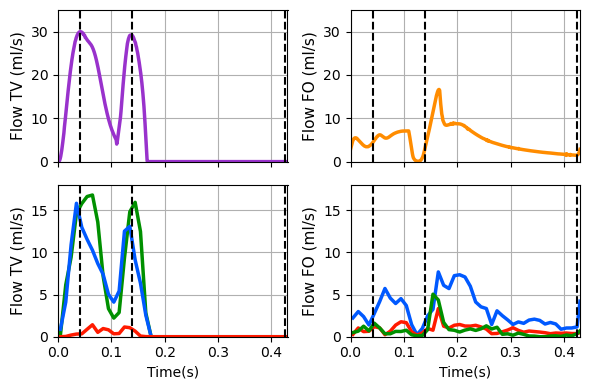

In [24]:
import numpy as np
import matplotlib.pyplot as plt

bin_size = 10

plt.figure(figsize=(6,4))

# ============================
# 1) Flow TV (original)
# ============================
plt.subplot(2,2,1)
plt.plot(time_ansys[:-1]-1.72, -flow_tv_ansys[:-1]*1e6/1050,
         linewidth=2.5, color='darkorchid')
plt.axvline(0.042,linestyle='--',color='k')
plt.axvline(0.139,linestyle='--',color='k')
plt.axvline(0.425,linestyle='--',color='k')
plt.xlim([0,0.43])
plt.ylim([0,35])
plt.ylabel('Flow TV (ml/s)', fontsize=11)
plt.grid()
plt.gca().set_xticklabels([])

# ============================
# 2) Flow FO (original)
# ============================
plt.subplot(2,2,2)
plt.plot(time_ansys[:-1]-1.72, -flow_fo_ansys[:-1]*1e6/1050,
         linewidth=2.5, color='darkorange')
plt.axvline(0.042,linestyle='--',color='k')
plt.axvline(0.139,linestyle='--',color='k')
plt.axvline(0.425,linestyle='--',color='k')
plt.xlim([0,0.43])
plt.ylim([0,35])
plt.ylabel('Flow FO (ml/s)', fontsize=11)
plt.grid()
plt.gca().set_xticklabels([])

# ============================
# 7) SVC -> TV (histograma)
# ============================
plt.subplot(2,2,3)
x = (flow_svc["time_step"] - flow_svc["time_step"].iloc[0]) / 1000
y = flow_svc["TV"] * 1e6 / 1050 / 10
x_bin, y_bin = bin_timeseries(x, y, bin_size=bin_size, mode="mean")
bar_width = (x.iloc[1] - x.iloc[0]) * bin_size if len(x) > 1 else 0.005
plt.plot(x_bin, y_bin, linewidth=2.5, color='#009000')

x = (flow_ivc["time_step"] - flow_ivc["time_step"].iloc[0]) / 1000
y = flow_ivc["TV"] * 1e6 / 1050 / 10
x_bin, y_bin = bin_timeseries(x, y, bin_size=bin_size, mode="mean")
plt.plot(x_bin, y_bin, linewidth=2.5, color='#0059FF')

x = (flow_dv["time_step"] - flow_dv["time_step"].iloc[0]) / 1000
y = flow_dv["TV"] * 1e6 / 1050 / 10
x_bin, y_bin = bin_timeseries(x, y, bin_size=bin_size, mode="mean")
plt.plot(x_bin, y_bin, linewidth=2.5, color='#FF1A00')

plt.axvline(0.042,linestyle='--',color='k')
plt.axvline(0.139,linestyle='--',color='k')
plt.axvline(0.425,linestyle='--',color='k')
plt.xlim([0,0.43])
plt.ylim([0,18])
plt.xlabel("Time(s)")
plt.ylabel("Flow TV (ml/s)", fontsize=11)
plt.grid()

# ============================
# 8) SVC -> FO (histograma)
# ============================
plt.subplot(2,2,4)

x = (flow_ivc["time_step"] - flow_ivc["time_step"].iloc[0]) / 1000
y = flow_ivc["FO"] * 1e6 / 1050 / 10
x_bin, y_bin = bin_timeseries(x, y, bin_size=bin_size, mode="mean")
plt.plot(x_bin, y_bin, linewidth=2.5, color='#0059FF')

x = (flow_dv["time_step"] - flow_dv["time_step"].iloc[0]) / 1000
y = flow_dv["FO"] * 1e6 / 1050 / 10
x_bin, y_bin = bin_timeseries(x, y, bin_size=bin_size, mode="mean")
plt.plot(x_bin, y_bin, linewidth=2.5, color='#FF1A00')

x = (flow_svc["time_step"] - flow_svc["time_step"].iloc[0]) / 1000
y = flow_svc["FO"] * 1e6 / 1050 / 10
x_bin, y_bin = bin_timeseries(x, y, bin_size=bin_size, mode="mean")
bar_width = (x.iloc[1] - x.iloc[0]) * bin_size if len(x) > 1 else 0.005
plt.plot(x_bin, y_bin, linewidth=2.5, color='#009000')

plt.axvline(0.042,linestyle='--',color='k')
plt.axvline(0.139,linestyle='--',color='k')
plt.axvline(0.425,linestyle='--',color='k')
plt.xlim([0,0.43])
plt.ylim([0,18])
plt.xlabel("Time(s)")
plt.ylabel("Flow FO (ml/s)", fontsize=11)
plt.grid()

plt.tight_layout()
plt.savefig("Flows_reference_histogram.pdf", bbox_inches="tight")
plt.show()

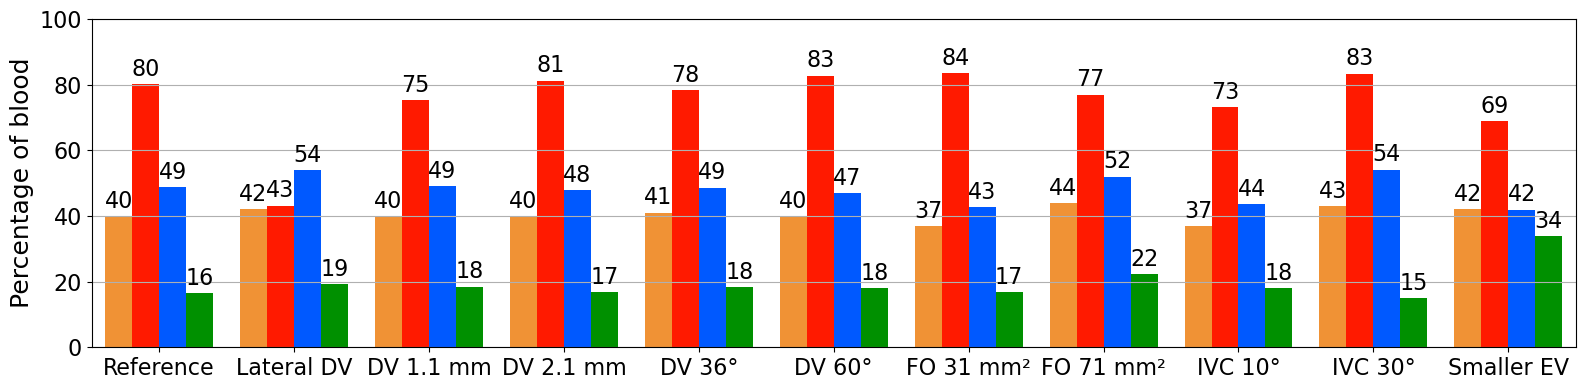

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ruta del archivo Excel
file_path = "particle_proportions_EV_summary.xlsx"

# Leer solo la hoja FO
df = pd.read_excel(file_path, sheet_name="FO")

# Nombres personalizados para las simulaciones
simulations = [
    'Reference',
    'Lateral DV',
    'DV 1.1 mm',
    'DV 2.1 mm',
    'DV 36°',
    'DV 60°',
    'FO 31 mm²',
    'FO 71 mm²',
    'IVC 10°',
    'IVC 30°',
    'Smaller EV'
]

dv = df["DV"]
ivc = df["IVC"]
svc = df["SVC"]
total = df["Total"]

# Posiciones en el eje X
x = np.arange(len(simulations))
width = 0.2

# Crear figura
plt.figure(figsize=(16, 4))

# Crear barras
bars_total = plt.bar(x - 3*width/2, total, width=width, color="#F09235", label="Total")
bars_dv = plt.bar(x - width/2, dv, width=width, color="#FF1A00", label="DV")
bars_ivc = plt.bar(x + width/2, ivc, width=width, color="#0059FF", label="IVC")
bars_svc = plt.bar(x + 3*width/2, svc, width=width, color="#009000", label="SVC")

# Función para añadir etiquetas
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.0f}",
            ha="center",
            va="bottom",
            fontsize=16
        )

# Añadir etiquetas
add_labels(bars_total)
add_labels(bars_dv)
add_labels(bars_ivc)
add_labels(bars_svc)

# Formato del gráfico
plt.xticks(x, simulations, rotation=0, ha="center", fontsize=16)
plt.yticks(fontsize=16)

plt.ylabel("Percentage of blood", fontsize=18)
#plt.legend(fontsize=14, loc='upper right')
plt.xlim(-0.5, len(simulations) - 0.5)
plt.ylim(0, 100)
plt.grid(axis="y")

plt.tight_layout()
plt.savefig("EV.pdf", bbox_inches="tight")
plt.show()

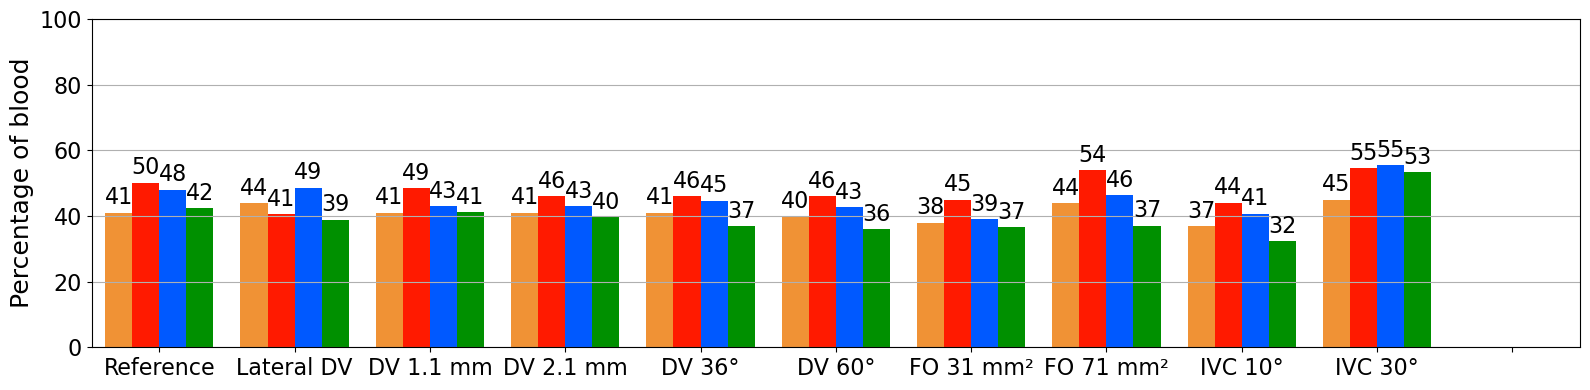

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ruta del archivo Excel
file_path = "particle_proportions_noEV_summary.xlsx"

# Leer solo la hoja FO
df = pd.read_excel(file_path, sheet_name="FO")

# Nombres completos de simulaciones (igual que en EV)
simulations = [
    'Reference',
    'Lateral DV',
    'DV 1.1 mm',
    'DV 2.1 mm',
    'DV 36°',
    'DV 60°',
    'FO 31 mm²',
    'FO 71 mm²',
    'IVC 10°',
    'IVC 30°',
    ''
]

# Leer datos del archivo noEV (solo 10 filas)
total_raw = df["Total"].to_numpy()
dv_raw = df["DV"].to_numpy()
ivc_raw = df["IVC"].to_numpy()
svc_raw = df["SVC"].to_numpy()

# Crear arrays de longitud 11, dejando la última posición vacía
total = np.full(len(simulations), np.nan)
dv = np.full(len(simulations), np.nan)
ivc = np.full(len(simulations), np.nan)
svc = np.full(len(simulations), np.nan)

total[:len(total_raw)] = total_raw
dv[:len(dv_raw)] = dv_raw
ivc[:len(ivc_raw)] = ivc_raw
svc[:len(svc_raw)] = svc_raw

# Posiciones en el eje X
x = np.arange(len(simulations))
width = 0.2

# Crear figura con exactamente el mismo tamaño
plt.figure(figsize=(16, 4))

# Crear barras
bars_total = plt.bar(x - 3*width/2, total, width=width, color="#F09235", label="Total")
bars_dv = plt.bar(x - width/2, dv, width=width, color="#FF1A00", label="DV")
bars_ivc = plt.bar(x + width/2, ivc, width=width, color="#0059FF", label="IVC")
bars_svc = plt.bar(x + 3*width/2, svc, width=width, color="#009000", label="SVC")

# Función para añadir etiquetas, ignorando NaN
def add_labels(bars, values):
    for bar, value in zip(bars, values):
        if not np.isnan(value):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                value + 1,
                f"{value:.0f}",
                ha="center",
                va="bottom",
                fontsize=16
            )

# Añadir etiquetas
add_labels(bars_total, total)
add_labels(bars_dv, dv)
add_labels(bars_ivc, ivc)
add_labels(bars_svc, svc)

# Formato del gráfico: exactamente igual que en EV
plt.xticks(x, simulations, rotation=0, ha="center", fontsize=16)
plt.yticks(fontsize=16)

plt.ylabel("Percentage of blood", fontsize=18)
#plt.legend(fontsize=14, loc='upper right')
plt.ylim(0, 100)
plt.xlim(-0.5, len(simulations) - 0.5)
plt.grid(axis="y")

plt.tight_layout()
plt.savefig("noEV.pdf", bbox_inches="tight")
plt.show()